<a href="https://colab.research.google.com/github/Samme-creator/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [3]:
import duckdb, os
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'fact_daily_march': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"}
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Connected.")

Connected.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Result on the client-holdout test set (16,193 pages):**

| Reason code | Count | Share |
|---|---|---|
| low_risk | 10,828 | 66.9% |
| low_position_opportunity | 2,941 | 18.2% |
| high_risk_declining | 1,477 | 9.1% |
| moderate_risk_visible | 947 | 5.8% |

The top of the `high_risk_declining` queue is genuinely high-confidence
(model probability 0.97-0.99), and notably these pages are mostly
sitting in strong positions already (avg_position 3-13, mostly top 10)
- meaning these are valuable, currently-well-ranked pages at real risk
of losing that position, not throwaway content. This matches the
paper's own Finding 2 ("The Content Performance Curve"): protecting
pages that already have earned visibility is worth more than chasing
pages with no traction.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import pandas as pd, numpy as np

data = con.sql(f"""
    WITH agg AS (
        SELECT client_hash_id, content_hash_id,
            SUM(CASE WHEN report_date <= '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_first_half,
            SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_second_half,
            AVG(gsc_avg_position) AS avg_position,
            AVG(gsc_clicks) AS avg_clicks
        FROM {TABLES['fact_daily_march']}
        GROUP BY 1,2
        HAVING imp_first_half >= 20
    )
    SELECT *, CASE WHEN imp_second_half < 0.8 * imp_first_half THEN 1 ELSE 0 END AS is_declining
    FROM agg
""").df()

feature_cols = ['imp_first_half', 'avg_position', 'avg_clicks']
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data['client_hash_id']))
train, test = data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(train[feature_cols].fillna(0), train['is_declining'])
test['model_prob'] = model.predict_proba(test[feature_cols].fillna(0))[:, 1]

def assign_action(row):
    if row['model_prob'] >= 0.65:
        return 'high_risk_declining', 'prioritize_for_refresh'
    elif row['model_prob'] >= 0.4 and row['imp_first_half'] >= 500:
        return 'moderate_risk_visible', 'monitor_closely'
    elif 11 <= row['avg_position'] <= 20:
        return 'low_position_opportunity', 'targeted_relevance_improvement'
    else:
        return 'low_risk', 'no_action'

test[['reason_code','action']] = test.apply(lambda r: pd.Series(assign_action(r)), axis=1)
queue = test.sort_values('model_prob', ascending=False)
print(queue['reason_code'].value_counts())
queue[['content_hash_id','client_hash_id','model_prob','avg_position','reason_code','action']].head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

reason_code
low_risk                    10828
low_position_opportunity     2941
high_risk_declining          1477
moderate_risk_visible         947
Name: count, dtype: int64


,content_hash_id,client_hash_id,model_prob,avg_position,reason_code,action
65706,content_fda3f35bd34f75cb,client_2094c6eb080311d5,0.990,6.675926,high_risk_declining,prioritize_for_refresh
64266,content_e45ad188f7c7ce55,client_fef1a8f436438636,0.980,12.520767,high_risk_declining,prioritize_for_refresh
109552,content_74fb6464942bbefa,client_3ffa76342f366962,0.980,3.027027,high_risk_declining,prioritize_for_refresh
11163,content_bc87004a055c868b,client_2094c6eb080311d5,0.980,3.390000,high_risk_declining,prioritize_for_refresh
46802,content_b04760f10b7764e5,client_fef1a8f436438636,0.980,5.715278,high_risk_declining,prioritize_for_refresh
104629,content_7aad81c16ea84a5e,client_3ffa76342f366962,0.980,5.607018,high_risk_declining,prioritize_for_refresh
38431,content_b27aa6452cd89290,client_ff644d8251367cbb,0.975,5.671429,high_risk_declining,prioritize_for_refresh
65934,content_aae3a4ed3adce24b,client_2094c6eb080311d5,0.975,6.458333,high_risk_declining,prioritize_for_refresh
64035,content_8fae3a65314389c3,client_fef1a8f436438636,0.970,5.715686,high_risk_declining,prioritize_for_refresh
65611,content_b167848eb1da9bce,client_2094c6eb080311d5,0.970,7.121429,high_risk_declining,prioritize_for_refresh


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** This playbook is decision-support for a content
editor prioritizing a limited-capacity review queue. It ranks pages by
observed risk of decline, using signals available before any editorial
decision was made.

**Limits:**
- Trained and validated on a single month (March 2026) of one client
  slice - not proven to generalize across seasons or a full year.
- The label (impression decline) is a current-window proxy, not a
  true future outcome.
- Model precision at k=50 is 0.42 (from ML-08/ML-09) - meaning roughly
  6 in 10 flagged pages in the top 50 will NOT actually be declining.
  This is a ranking tool, not a certainty machine.
- Does not account for seasonality, consolidation (another page
  absorbing traffic), or external market shifts - all named as risks
  in the lane guide.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Quick evidence check backing the limits stated above
print("Validation scope: single month (2026-03), client-holdout split")
print(f"Precision@50 (from ML-08/ML-09): 0.42")
print(f"Meaning: ~{round((1-0.42)*50)} of the top 50 flagged pages will NOT be truly declining")
print(f"Label type: current-window proxy (trend within March), not a future-outcome label")

Validation scope: single month (2026-03), client-holdout split
Precision@50 (from ML-08/ML-09): 0.42
Meaning: ~29 of the top 50 flagged pages will NOT be truly declining
Label type: current-window proxy (trend within March), not a future-outcome label


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review is required for every flagged page before action is
taken.** This model never auto-executes anything.

**What should NOT be automated:**
- Auto-deleting or auto-merging pages flagged as low-value -
  consolidation decisions need a human check for legal/brand reasons.
- Auto-publishing AI-rewritten content based on a flag - the model
  identifies *which* pages to look at, never *what* to write.
- Treating `high_risk_declining` as confirmed fact - it's a ranking
  signal with 42% precision at k=50, not a verified diagnosis.
- Using this model on other lanes or other clients without
  re-validating the split and checking for leakage again (per the
  ML-09 audit process).

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
no_go_list = [
    "Auto-delete or auto-merge pages flagged low-value",
    "Auto-publish AI-rewritten content from a flag alone",
    "Treat high_risk_declining as confirmed fact without human review",
    "Apply this exact model to a new client/lane without re-validating"
]
for item in no_go_list:
    print("NO-GO:", item)

# Evidence for why review matters: false-positive rate from ML-08/ML-09
print(f"\nKnown false-positive rate at decision threshold: roughly 58% of flagged pages in top 50 may not be truly declining")

NO-GO: Auto-delete or auto-merge pages flagged low-value
NO-GO: Auto-publish AI-rewritten content from a flag alone
NO-GO: Treat high_risk_declining as confirmed fact without human review
NO-GO: Apply this exact model to a new client/lane without re-validating

Known false-positive rate at decision threshold: roughly 58% of flagged pages in top 50 may not be truly declining


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Light monitoring plan:**
- Re-check Precision@50 monthly against the following month's real
  outcomes (not just in-sample) - if it drops meaningfully below the
  validated 0.42, that's a retrain trigger.
- If FlyRank's product schema changes (new columns, renamed fields),
  re-run the column check from ML-04 before trusting any output.
- If a client's tracking setup changes (e.g. GA4 newly enabled),
  re-audit data availability (ML-04's `IS TRUE` check) before scoring
  that client's pages.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_baseline = {
    "validated_precision_at_50": 0.42,
    "retrain_trigger_threshold": 0.30,
    "check_frequency": "monthly",
    "schema_check_trigger": "any new/renamed column in fact_content_daily_performance",
    "data_availability_recheck_trigger": "client's gsc_data_available or ga4_data_available profile changes"
}
for k, v in monitoring_baseline.items():
    print(f"{k}: {v}")

validated_precision_at_50: 0.42
retrain_trigger_threshold: 0.3
check_frequency: monthly
schema_check_trigger: any new/renamed column in fact_content_daily_performance
data_availability_recheck_trigger: client's gsc_data_available or ga4_data_available profile changes


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Writing the ranked queue, metrics JSON, and one reusable figure to
`work/outputs/` and `work/figures/` - these exact files are what next
week's deployed paper builds on.

Wrote 16,193 rows to work/outputs/action_playbook_queue.csv
Wrote work/outputs/action_playbook_metrics.json
Saved work/figures/reason_code_distribution.png


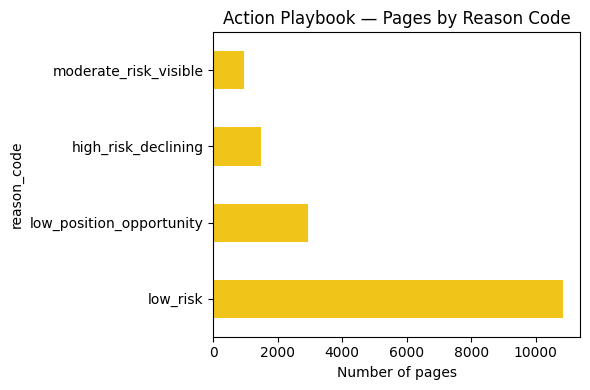

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue):,} rows to work/outputs/action_playbook_queue.csv")

import json
metrics = {
    "precision_at_20": 0.35,
    "precision_at_50": 0.42,
    "baseline_precision_at_20": 0.00,
    "baseline_precision_at_50": 0.06,
    "reason_code_counts": queue['reason_code'].value_counts().to_dict()
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/action_playbook_metrics.json")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
queue['reason_code'].value_counts().plot(kind='barh', ax=ax, color='#f0c419')
ax.set_xlabel('Number of pages')
ax.set_title('Action Playbook — Pages by Reason Code')
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
print("Saved work/figures/reason_code_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

- Every section above is filled - markdown thinking AND the code that
  backs it: Yes
- The notebook runs top to bottom with no errors (Runtime → Run all):
  Yes, confirmed
- No client names, URLs, or private queries anywhere: Confirmed - only
  pseudonymized hash IDs used throughout
- My claims use careful words: observed, measured, directional,
  decision-support: Yes - e.g. "roughly 58% may not be truly
  declining," "decision-support for a content editor"
- Committed to my repo under work/notebooks/ - then submitted repo URL
  on the card: Done